<a href="https://colab.research.google.com/github/Balamurugan-T326/DEEP-LEARNING/blob/main/EXPERIMENT-6/part-A%2CB%2CC%2CD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

PART A — Dataset Preparation and Text Preprocessing

In [28]:
print("24BAD016-BALAMURUGAN T")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer

from sklearn.model_selection import train_test_split

24BAD016-BALAMURUGAN T


Load IMDB Dataset

In [2]:

VOCAB_SIZE = 10000

(x_train, y_train), (x_test, y_test) = imdb.load_data(
    num_words=VOCAB_SIZE
)

print("Training samples:", len(x_train))
print("Testing samples:", len(x_test))

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training samples: 25000
Testing samples: 25000


Check Sentiment Distribution

In [3]:
print("Positive reviews in training:", np.sum(y_train == 1))
print("Negative reviews in training:", np.sum(y_train == 0))

print("Positive reviews in testing:", np.sum(y_test == 1))
print("Negative reviews in testing:", np.sum(y_test == 0))

Positive reviews in training: 12500
Negative reviews in training: 12500
Positive reviews in testing: 12500
Negative reviews in testing: 12500


Display Sample Reviews

In [4]:
word_index = imdb.get_word_index()

# Reverse word index
reverse_word_index = {
    value + 3: key for key, value in word_index.items()
}

reverse_word_index[0] = "<PAD>"
reverse_word_index[1] = "<START>"
reverse_word_index[2] = "<UNK>"
reverse_word_index[3] = "<UNUSED>"

def decode_review(sequence):
    return " ".join(
        reverse_word_index.get(i, "?") for i in sequence
    )

print("Sample Review:")
print(decode_review(x_train[0]))

print("\nActual Sentiment:")
print("Positive" if y_train[0] == 1 else "Negative")

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Sample Review:
<START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <UNK> is an amazing actor and now the same being director <UNK> father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for <UNK> and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also <UNK> to the two little boy's that played the <UNK> of norman and paul they were just brilliant children are often left out of the <UNK> list i think because the stars that play them all grown up are such a big profile for the whole f

Text Preprocessing

In [5]:
MAX_LENGTH = 200

# Padding sequences
x_train_pad = pad_sequences(
    x_train,
    maxlen=MAX_LENGTH,
    padding='post',
    truncating='post'
)

x_test_pad = pad_sequences(
    x_test,
    maxlen=MAX_LENGTH,
    padding='post',
    truncating='post'
)

print("Training data shape:", x_train_pad.shape)
print("Testing data shape:", x_test_pad.shape)

Training data shape: (25000, 200)
Testing data shape: (25000, 200)


Create Validation Dataset

In [6]:
x_train_final, x_val, y_train_final, y_val = train_test_split(
    x_train_pad,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

print("Training data:", x_train_final.shape)
print("Validation data:", x_val.shape)
print("Testing data:", x_test_pad.shape)

Training data: (20000, 200)
Validation data: (5000, 200)
Testing data: (25000, 200)


Display Prepared Data

In [7]:
print("First padded sequence:")
print(x_train_final[0])

print("\nFirst label:")
print(y_train_final[0])

print("\nFinal Shapes:")
print("X Train:", x_train_final.shape)
print("Y Train:", y_train_final.shape)
print("X Validation:", x_val.shape)
print("Y Validation:", y_val.shape)
print("X Test:", x_test_pad.shape)
print("Y Test:", y_test.shape)

First padded sequence:
[   1  806    8  135   13   28   57  326   51  363    9  399  252  202
  178  102   40 1354  778  449   34    4   96  363   13  104   36  203
 1108    4   65  347   11    4   20 1354   21  591   92 2836  178   51
   75   62   66  181    8   67 1354    5 1832  295   13   66 1800   14
 1472   88   12  317   72 1786   18   53   13   16  267  187    8   67
   54   12   16  582   46   12   16   40    6  394 7992  975    4 2876
  121   52    4   65  347  468 1156    5   12   69   32    4    2    7
    6   87   20  472   45   24  170    8  593   18  150    8    4 1180
  907    5   32    4  156   87  292   21   13  784   25   18  399   14
    8   72   25  317   72 1786   53    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    

PART B — Embedding Generation

In [8]:
EMBEDDING_DIM = 64

print("Vocabulary Size:", VOCAB_SIZE)
print("Embedding Dimension:", EMBEDDING_DIM)

Vocabulary Size: 10000
Embedding Dimension: 64


Create Embedding Layer

In [9]:
embedding_layer = tf.keras.layers.Embedding(
    input_dim=VOCAB_SIZE,
    output_dim=EMBEDDING_DIM,
    input_length=MAX_LENGTH
)

print("Embedding layer created successfully.")

Embedding layer created successfully.


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Generate Embedding Representation

In [10]:

sample_input = x_train_final[:2]


embedded_output = embedding_layer(sample_input)

print("Input shape:", sample_input.shape)
print("Embedding output shape:", embedded_output.shape)

Input shape: (2, 200)
Embedding output shape: (2, 200, 64)


Display Sample Embedding

In [11]:
print("Embedding representation of first review:")
print(embedded_output[0])

print("\nShape of first review embedding:")
print(embedded_output[0].shape)

Embedding representation of first review:
tf.Tensor(
[[ 0.02207835  0.04280526  0.00064055 ... -0.04498307 -0.01117174
  -0.03375379]
 [-0.02500191 -0.04338596 -0.0219533  ... -0.03056967 -0.0323984
  -0.03655331]
 [-0.00791633  0.00352007  0.00304426 ... -0.00196204 -0.02977122
  -0.00363407]
 ...
 [-0.04294756  0.04291911  0.03616829 ...  0.04083153  0.02565807
  -0.00559603]
 [-0.04294756  0.04291911  0.03616829 ...  0.04083153  0.02565807
  -0.00559603]
 [-0.04294756  0.04291911  0.03616829 ...  0.04083153  0.02565807
  -0.00559603]], shape=(200, 64), dtype=float32)

Shape of first review embedding:
(200, 64)


PART C — Implementing the LSTM Model

In [12]:
model = tf.keras.Sequential([

    tf.keras.layers.Input(shape=(MAX_LENGTH,)),

    tf.keras.layers.Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM
    ),

    tf.keras.layers.LSTM(64),

    tf.keras.layers.Dense(1, activation='sigmoid')
])

Compile Model

In [13]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully.")

Model compiled successfully.


Display Model Summary

In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 200, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 673,089 (2.57 MB)

 Trainable params: 673,089 (2.57 MB)

 Non-trainable params: 0 (0.00 B)

PART D — Model Training and Sentiment Prediction

In [15]:
history = model.fit(
    x_train_final,
    y_train_final,
    validation_data=(x_val, y_val),
    epochs=5,
    batch_size=64,
    verbose=1
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 56s 169ms/step - accuracy: 0.5343 - loss: 0.6880 - val_accuracy: 0.5162 - val_loss: 0.6913
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 59s 188ms/step - accuracy: 0.5440 - loss: 0.6858 - val_accuracy: 0.5336 - val_loss: 0.6861
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 79s 178ms/step - accuracy: 0.6008 - loss: 0.6461 - val_accuracy: 0.5446 - val_loss: 0.6817
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 54s 173ms/step - accuracy: 0.6034 - loss: 0.6404 - val_accuracy: 0.5326 - val_loss: 0.6898
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 98s 225ms/step - accuracy: 0.6875 - loss: 0.5558 - val_accuracy: 0.7812 - val_loss: 0.5004


Display Training Results

In [16]:
print("Final Training Accuracy:",
      history.history['accuracy'][-1])

print("Final Validation Accuracy:",
      history.history['val_accuracy'][-1])

print("Final Training Loss:",
      history.history['loss'][-1])

print("Final Validation Loss:",
      history.history['val_loss'][-1])

Final Training Accuracy: 0.6875
Final Validation Accuracy: 0.7811999917030334
Final Training Loss: 0.5557949542999268
Final Validation Loss: 0.5003982186317444


Accuracy vs Epoch

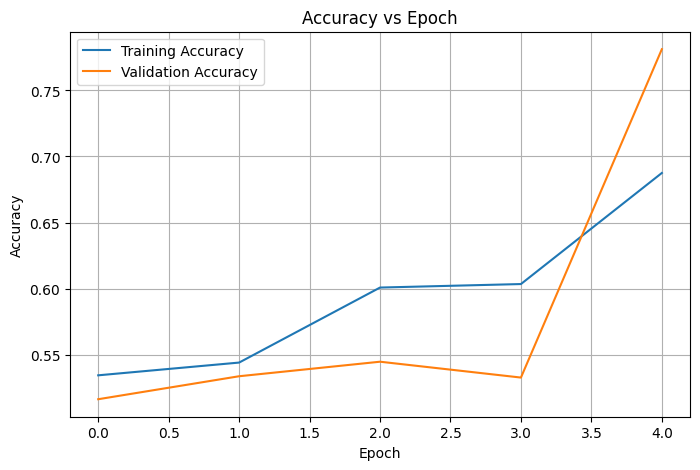

In [18]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title('Accuracy vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.show()

Loss vs Epoch

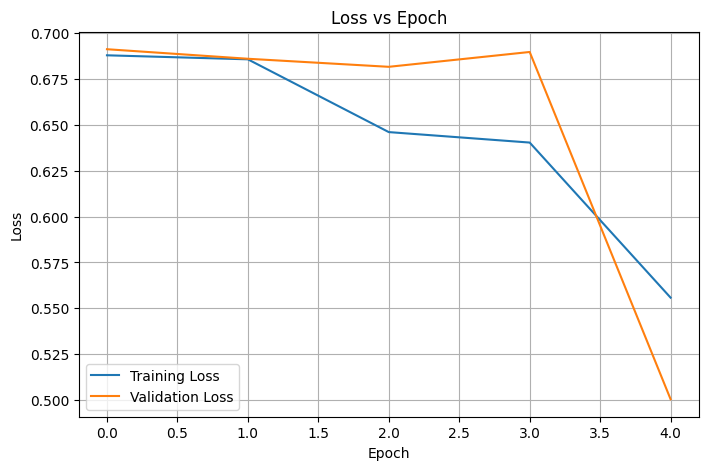

In [17]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.title('Loss vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

Test Dataset Evaluation

In [19]:
test_loss, test_accuracy = model.evaluate(
    x_test_pad,
    y_test,
    verbose=1
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

782/782 ━━━━━━━━━━━━━━━━━━━━ 25s 32ms/step - accuracy: 0.7696 - loss: 0.5099
Test Loss: 0.5098993182182312
Test Accuracy: 0.7696400284767151


Sentiment Prediction

In [20]:
predictions = model.predict(x_test_pad)

# Convert probabilities to 0 or 1
predicted_labels = (predictions >= 0.5).astype(int).flatten()

print("First 10 Predictions:")
print(predicted_labels[:10])

print("\nActual Labels:")
print(y_test[:10])

782/782 ━━━━━━━━━━━━━━━━━━━━ 24s 31ms/step
First 10 Predictions:
[0 1 1 0 1 1 0 1 1 1]

Actual Labels:
[0 1 1 0 1 1 1 0 0 1]


Sample Review Prediction

In [23]:
def predict_sentiment(review):

    # Convert review into words
    words = review.lower().split()

    # Convert words to integers
    sequence = []

    for word in words:
        index = word_index.get(word)

        if index is not None and index < VOCAB_SIZE:
            sequence.append(index + 3)
        else:
            sequence.append(2)

    # Padding
    sequence = pad_sequences(
        [sequence],
        maxlen=MAX_LENGTH,
        padding='post',
        truncating='post'
    )

    # Prediction
    probability = model.predict(sequence, verbose=0)[0][0]

    if probability >= 0.5:
        sentiment = "Positive"
    else:
        sentiment = "Negative"

    print("Review:", review)
    print("Sentiment:", sentiment)
    print("Probability:", probability)

Test Sample Reviews

In [22]:
predict_sentiment(
    "This movie was amazing and I really enjoyed watching it"
)

predict_sentiment(
    "This movie was boring and a complete waste of time"
)

Review: This movie was amazing and I really enjoyed watching it
Sentiment: Negative
Probability: 0.38311225
Review: This movie was boring and a complete waste of time
Sentiment: Negative
Probability: 0.23953177


In [24]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
accuracy = accuracy_score(
    y_test,
    predicted_labels
)

precision = precision_score(
    y_test,
    predicted_labels
)

recall = recall_score(
    y_test,
    predicted_labels
)

f1 = f1_score(
    y_test,
    predicted_labels
)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-Score :", f1)

Accuracy : 0.76964
Precision: 0.8126333364251924
Recall   : 0.70088
F1-Score : 0.7526309007345046


Classification Report

In [25]:
print(classification_report(
    y_test,
    predicted_labels,
    target_names=['Negative', 'Positive']
))

              precision    recall  f1-score   support

    Negative       0.74      0.84      0.78     12500
    Positive       0.81      0.70      0.75     12500

    accuracy                           0.77     25000
   macro avg       0.77      0.77      0.77     25000
weighted avg       0.77      0.77      0.77     25000



Generate Confusion Matrix

In [26]:
cm = confusion_matrix(
    y_test,
    predicted_labels
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[10480  2020]
 [ 3739  8761]]


Display Confusion Matrix

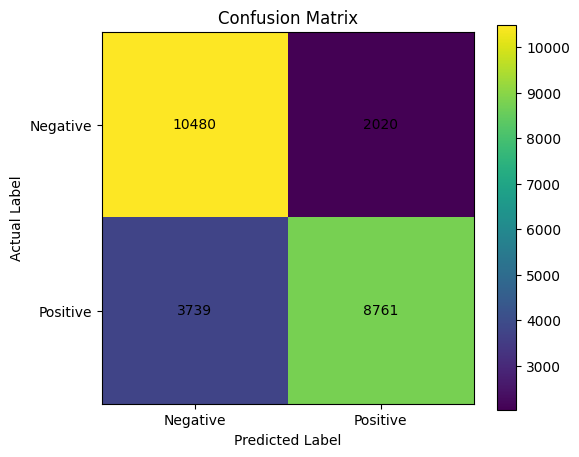

In [27]:
plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')

plt.xticks(
    [0, 1],
    ['Negative', 'Positive']
)

plt.yticks(
    [0, 1],
    ['Negative', 'Positive']
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha='center',
            va='center'
        )

plt.colorbar()
plt.show()